In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys         
import xarray as xr
import NooneCurves as NC 
import NooneCurves_ax as NC_ax
import pandas as pd
import seaborn as sns

In [3]:
# Some initial values for testing
del0 = -400.    # Try -360 ....
delp = -30. 
eta  = 0.995
hsrc = 0.80 
nn   = 1000     # It needs to be this large to get precision in the searches
pcld = 85000.
ps = 1000.e2                    # approximate surface pressure
q0   = 0.9 
qmin = 11.
tsrc = 300. 

In [4]:
band = 'EQ'
sat_ds_in = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/tropess_airs_eq_cb.nc')
sat_ds_in = sat_ds_in.rename({'time':'timedatum'})
ON1 = 62
CE1 = 142
ON2 = 247
CE2 = 341

In [5]:
level='low-mid'

sat_ds = sat_ds_in.where((sat_ds_in['pressure']>550)&(sat_ds_in['pressure']<825),drop=True)
#sat_ds = sat_ds_in.where(sat_ds_in['pressure']>825,drop=True)
#sat_ds = sat_ds_in.where(sat_ds_in['pressure']>550,drop=True)

sat_ds = sat_ds.sel(timedatum=slice('2018-01-01','2024-12-31'))

In [6]:
ON = ON1
CE = CE1
dry_r = ON-(20*4)
dry = 365+dry_r
pppon = ON-(20*3)
ppon = ON-(20*2)
pon = ON-20
on = ON
ons = ON+20
onss = ON+(20*2)
pcesson = CE-(20*2)
cesson = CE-20
cess = CE
cesss = CE+20

print(dry)
print(dry_r+20)


347
2


In [7]:
#S1

seas1 = {}
seas1['80-60 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>dry)&(sat_ds['timedatum.dayofyear']<dry_r+20),drop=True)
seas1['60-40 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pppon)&(sat_ds['timedatum.dayofyear']<pppon+20),drop=True)
seas1['40-20 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>ppon)&(sat_ds['timedatum.dayofyear']<ppon+20),drop=True)
seas1['20 days to onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pon)&(sat_ds['timedatum.dayofyear']<pon+20),drop=True)
seas1['onset to 20 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>on)&(sat_ds['timedatum.dayofyear']<on+20),drop=True)
seas1['20-40 days post-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>ons)&(sat_ds['timedatum.dayofyear']<ons+20),drop=True)
seas1['40-60 days post-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>onss)&(sat_ds['timedatum.dayofyear']<onss+20),drop=True)

#seas1['40-20 days pre-cessation'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pcesson)&(sat_ds['timedatum.dayofyear']<pcesson+20),drop=True)
seas1['20 days to cessation'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cesson)&(sat_ds['timedatum.dayofyear']<cesson+20),drop=True)
seas1['cessation to post-20 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cess)&(sat_ds['timedatum.dayofyear']<cess+20),drop=True)
#seas1['post 20 days - post 40 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cesss)&(sat_ds['timedatum.dayofyear']<cesss+20),drop=True)

print(seas1['80-60 days pre-onset'].timedatum)


<xarray.DataArray 'timedatum' (timedatum: 0)> Size: 0B
array([], dtype='datetime64[ns]')
Coordinates:
  * timedatum  (timedatum) datetime64[ns] 0B 


In [8]:
#for s in seas1:
#    
#    deltaD = seas1[s]['deltaD']
#    qh2o = 1000.*seas1[s]['H2O']
#    
#    
#    plt.xlim(0,40)
#    plt.ylim(-400,50)
#    plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')
#
#    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot
#    
#    plt.legend(loc='best')
#    plt.title(band+' S1 - '+s)
#    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/TROPESS_noone_curves_'+band+'_S1_'+level+'.png')
#
#    plt.show()
#    plt.clf()
#    plt.close()

/var/folders/jw/q6mk24x56jlf267q35mtsdfh0000gn/T/ipykernel_16677/3611064396.py:17: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x="H2O", y="deltaD", fill=True,


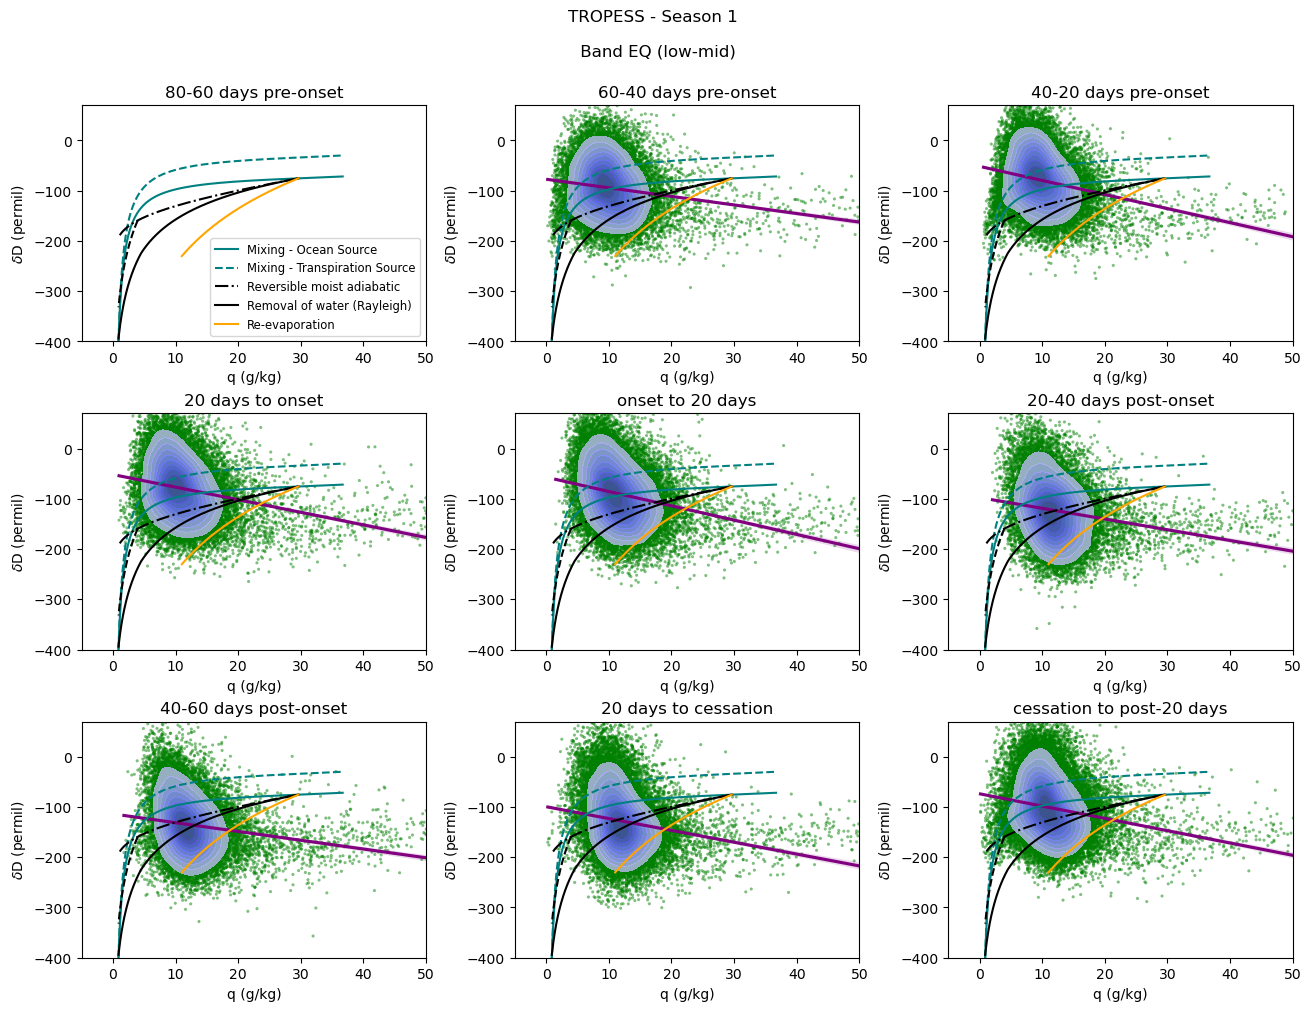

In [9]:

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=3
nrows=3
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(13,10))
axs=axs.flatten()
for i,s in enumerate(seas1):
    
    df = seas1[s].to_dataframe()
    df['H2O'] = df['H2O']*1000.

    sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs[i])
    sns.kdeplot(data=df, x="H2O", y="deltaD", fill=True,
                alpha=0.8,color='blue',ax=axs[i],zorder=1,thresh=.2)
    axs[i].set_xlim(-5,50)
    axs[i].set_ylim(-400,70)
    axs[i].scatter(1000.*seas1[s]['H2O'],seas1[s]['deltaD'],s=5,alpha=0.5,edgecolors='none',c='green',zorder=0)
    NC_ax.noone_curves(tsrc,q0,del0,ax=axs[i])    # Run and produce plot
    axs[i].set_title(s)
    if i==0:
        axs[i].legend(loc='best',fontsize='small')
plt.suptitle('TROPESS - Season 1 \n \n Band '+band+' ('+level+')\n')
plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/TROPESS_noone_curves_'+band+'_S1_'+level+'.png',transparent=True)

plt.show()
plt.clf()
plt.close()

In [10]:
ON = ON2
CE = CE2
dry = ON-(20*4)
pppon = ON-(20*3)
ppon = ON-(20*2)
pon = ON-20
on = ON
ons = ON+20
onss = ON+(20*2)
pcesson = CE-(20*2)
cesson = CE-20
cess = CE
cesss = CE+20
print(dry)
print(dry+20)


167
187


In [11]:
#S2

seas2 = {}
seas2['80-60 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>dry)&(sat_ds['timedatum.dayofyear']<dry+20),drop=True)
seas2['60-40 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pppon)&(sat_ds['timedatum.dayofyear']<pppon+20),drop=True)
seas2['40-20 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>ppon)&(sat_ds['timedatum.dayofyear']<ppon+20),drop=True)
seas2['20 days to onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pon)&(sat_ds['timedatum.dayofyear']<pon+20),drop=True)
seas2['onset to 20 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>on)&(sat_ds['timedatum.dayofyear']<on+20),drop=True)
seas2['20-40 days post-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>ons)&(sat_ds['timedatum.dayofyear']<ons+20),drop=True)
seas2['40-60 days post-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>onss)&(sat_ds['timedatum.dayofyear']<onss+20),drop=True)

#seas2['40-20 days pre-cessation'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pcesson)&(sat_ds['timedatum.dayofyear']<pcesson+20),drop=True)
seas2['20 days to cessation'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cesson)&(sat_ds['timedatum.dayofyear']<cesson+20),drop=True)
seas2['cessation to post-20 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cess)&(sat_ds['timedatum.dayofyear']<cess+20),drop=True)
#seas2['post 20 days - post 40 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cesss)&(sat_ds['timedatum.dayofyear']<cesss+20),drop=True)

In [12]:
#for s in seas2:
#    
#    deltaD = seas2[s]['deltaD']
#    qh2o = 1000.*seas2[s]['H2O']
#    
#    plt.xlim(0,40)
#    plt.ylim(-400,50)
#    plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')
#
#    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot
#
#    plt.legend(loc='best')
#    plt.title(band+' S2 - '+s)
#    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/TROPESS_noone_curves_'+band+'_S2_'+level+'.png')
#
#    plt.show()
#    plt.clf()
#    plt.close()
#    

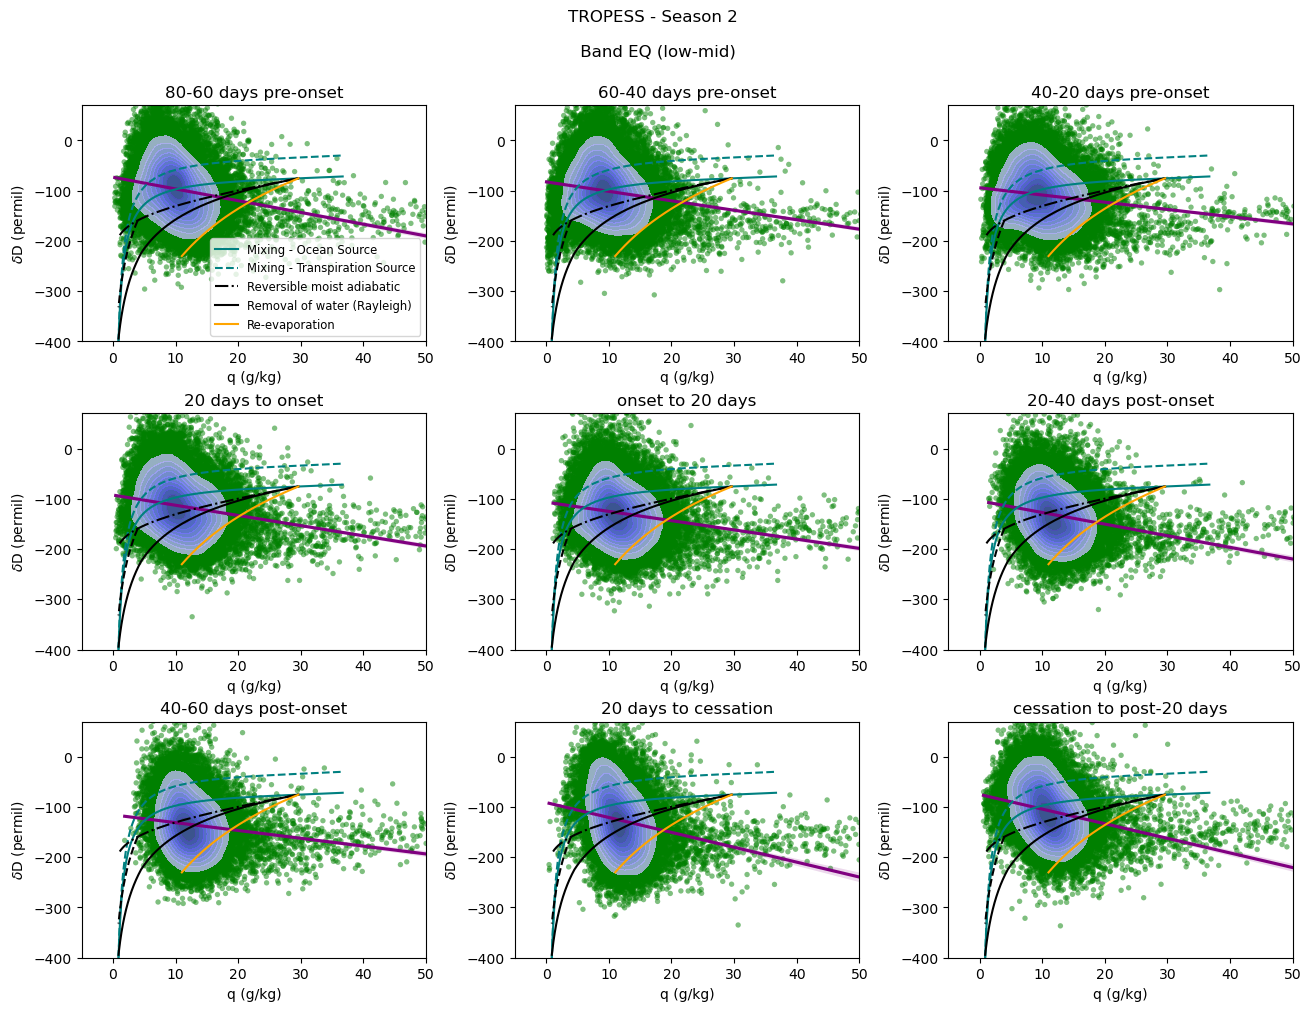

In [13]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=3
nrows=3
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(13,10))
axs=axs.flatten()
for i,s in enumerate(seas2):
    
    df = seas2[s].to_dataframe()
    df['H2O'] = df['H2O']*1000.

    sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs[i])
    sns.kdeplot(data=df, x="H2O", y="deltaD", fill=True,
                alpha=0.8,color='blue',ax=axs[i],zorder=1,thresh=.2)
    axs[i].set_xlim(-5,50)
    axs[i].set_ylim(-400,70)
    axs[i].scatter(1000.*seas2[s]['H2O'],seas2[s]['deltaD'],s=15,alpha=0.5,edgecolors='none',c='green',zorder=0)
    NC_ax.noone_curves(tsrc,q0,del0,ax=axs[i])    # Run and produce plot
    axs[i].set_title(s)
    if i==0:
        axs[i].legend(loc='best',fontsize='small')
plt.suptitle('TROPESS - Season 2 \n \n Band '+band+' ('+level+')\n')
plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/TROPESS_noone_curves_'+band+'_S2_'+level+'.png',transparent=True)

plt.show()
plt.clf()
plt.close()